<a href="https://colab.research.google.com/github/RatchanonPa/Data-Warehouse-and-Big-Data-Analytics/blob/main/Datasci%20Hack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# prompt: unzip /content/hearth-disease-recognition.zip

!unzip /content/hearth-disease-recognition.zip


Archive:  /content/hearth-disease-recognition.zip
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [7]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.4 MB/s eta 0:00:00


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import fbeta_score, make_scorer, confusion_matrix, classification_report

# Load Data

In [9]:
# --- 1. Load Data ---
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')
sample_submission = pd.read_csv('/content/sample_submission.csv')

In [10]:
print(train_df.info())
print(train_df.describe())
train_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223084 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      223084 non-null  object 
 1   History of HeartDisease or Attack       221390 non-null  object 
 2   High Blood Pressure                     223084 non-null  object 
 3   Told High Cholesterol                   190898 non-null  object 
 4   Cholesterol Checked                     223084 non-null  object 
 5   Body Mass Index                         211302 non-null  float64
 6   Smoked 100+ Cigarettes                  223083 non-null  object 
 7   Diagnosed Stroke                        223084 non-null  object 
 8   Diagnosed Diabetes                      223081 non-null  object 
 9   Leisure Physical Activity               223084 non-null  object 
 10  Heavy Alcohol Consumption               2230

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,NaN,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes


In [11]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

ID                                            0
History of HeartDisease or Attack          1694
High Blood Pressure                           0
Told High Cholesterol                     32186
Cholesterol Checked                           0
Body Mass Index                           11782
Smoked 100+ Cigarettes                        1
Diagnosed Stroke                              0
Diagnosed Diabetes                            3
Leisure Physical Activity                     0
Heavy Alcohol Consumption                     0
Health Care Coverage                          0
Doctor Visit Cost Barrier                     1
General Health                                1
Difficulty Walking                            3
Sex                                           0
Education Level                               0
Income Level                                  0
Age                                           0
Vegetable or Fruit Intake (1+ per Day)        0
dtype: int64
ID                         

History of HeartDisease or Attack
No     203322
Yes     18068
Name: count, dtype: int64


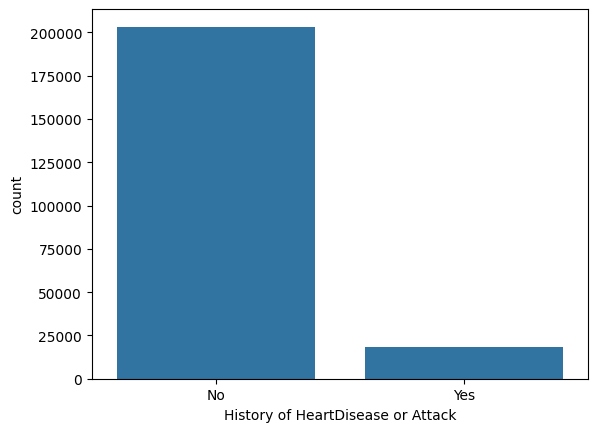

In [12]:
print(train_df['History of HeartDisease or Attack'].value_counts())
sns.countplot(x='History of HeartDisease or Attack', data=train_df)
plt.show()

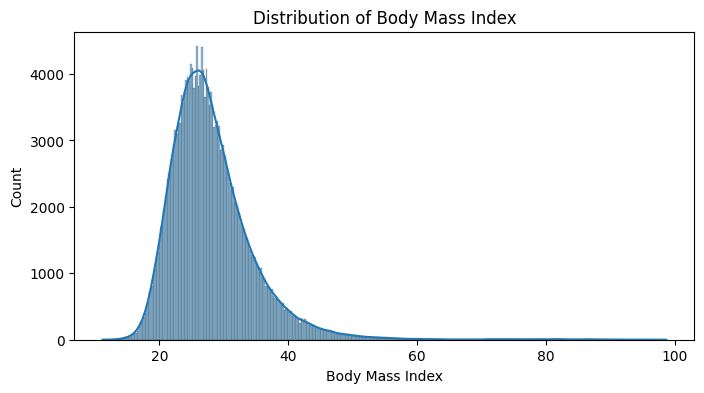

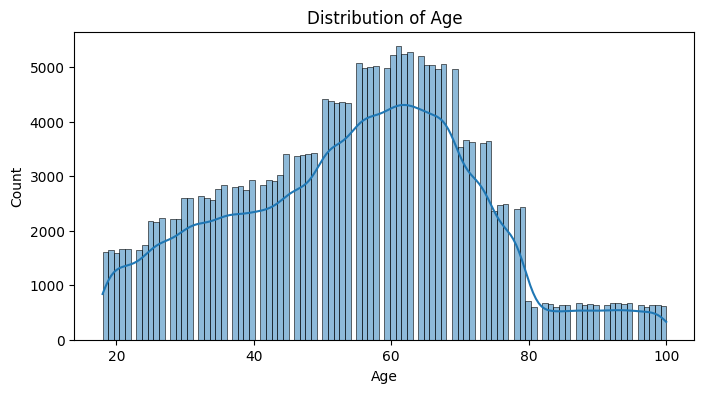

In [13]:
numerical_cols = ['Body Mass Index', 'Age']
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

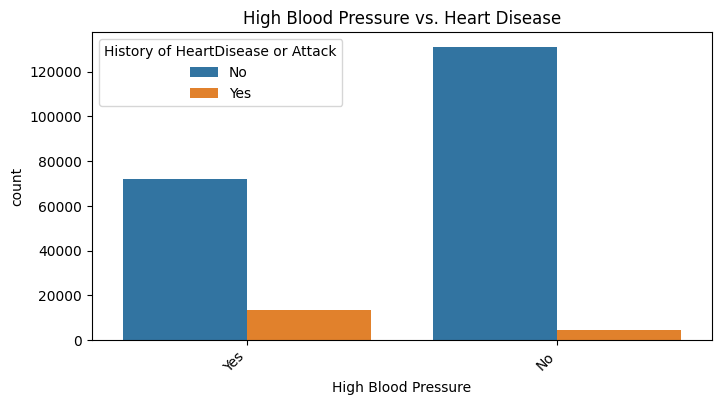

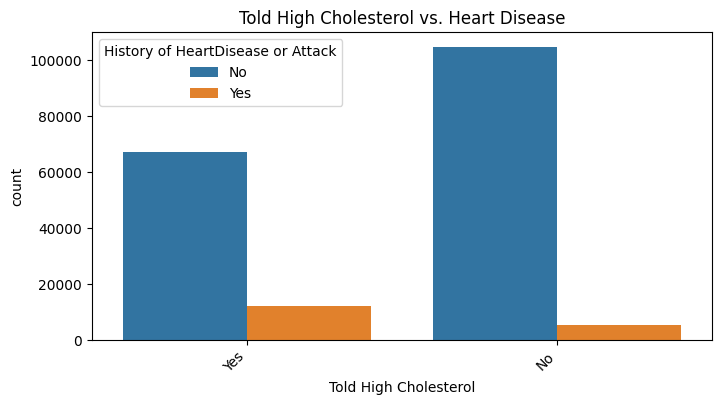

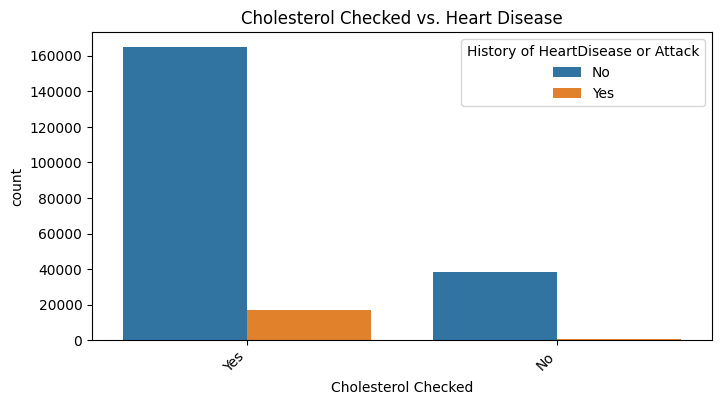

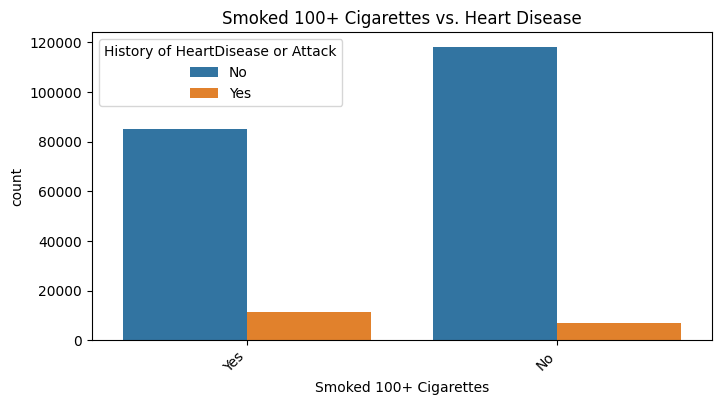

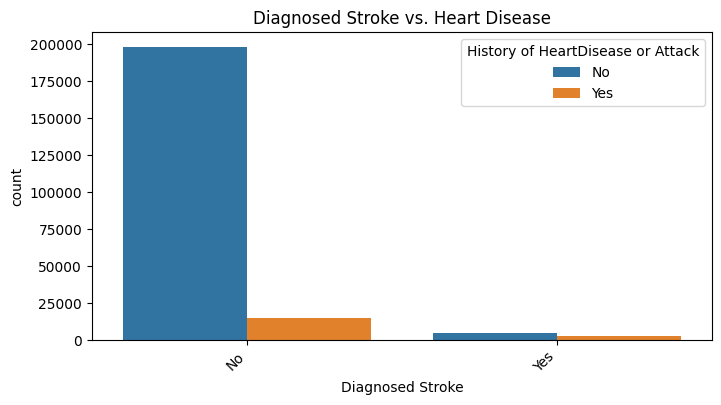

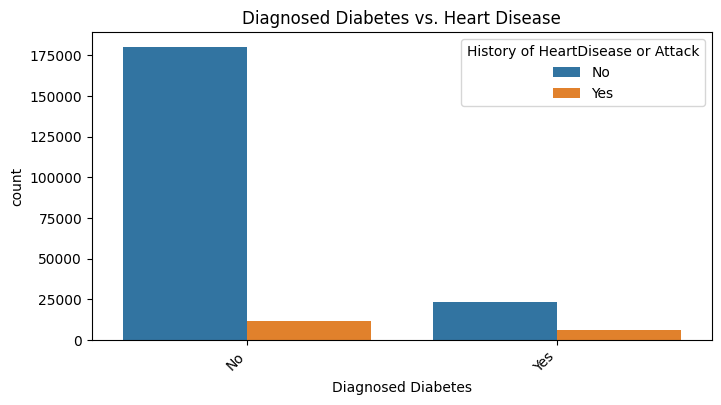

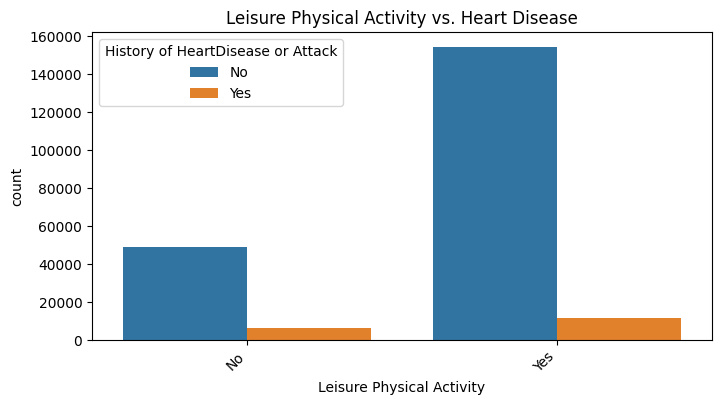

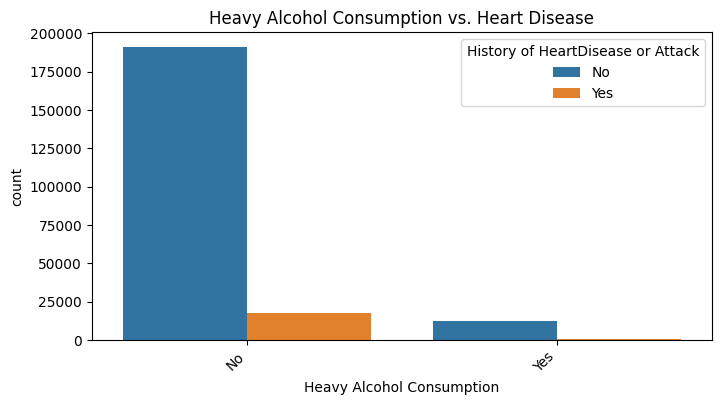

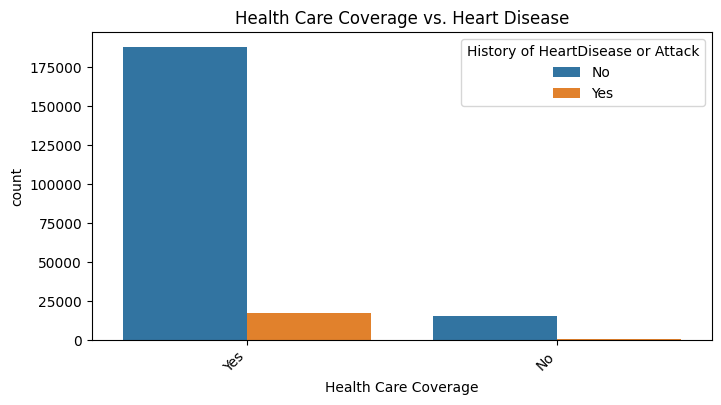

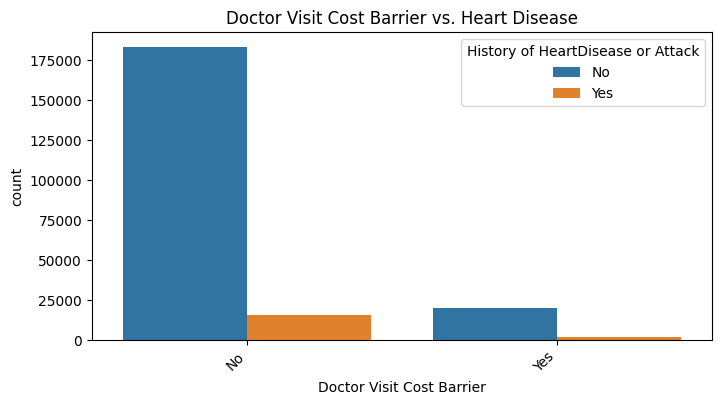

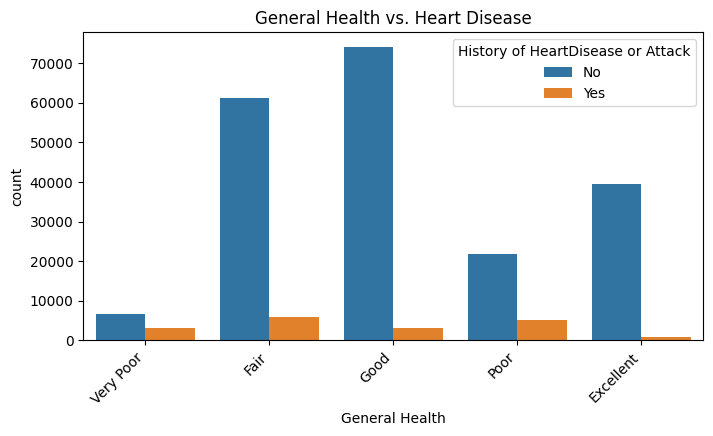

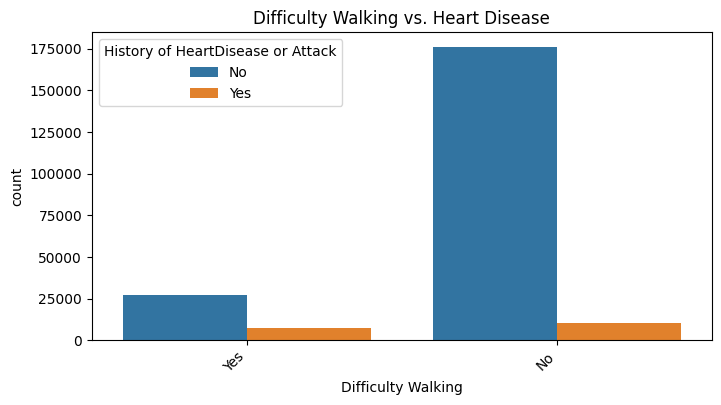

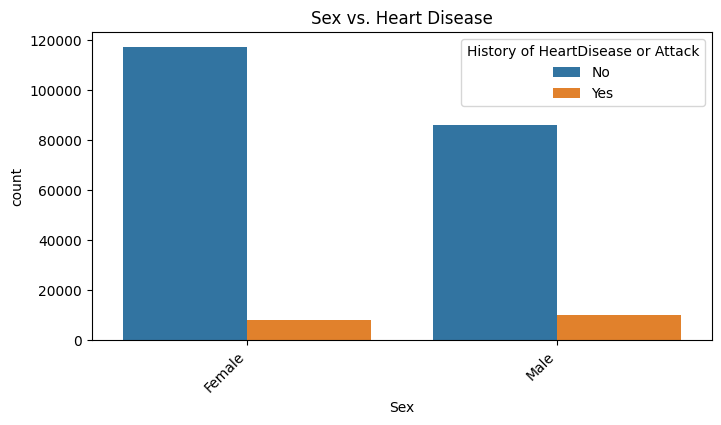

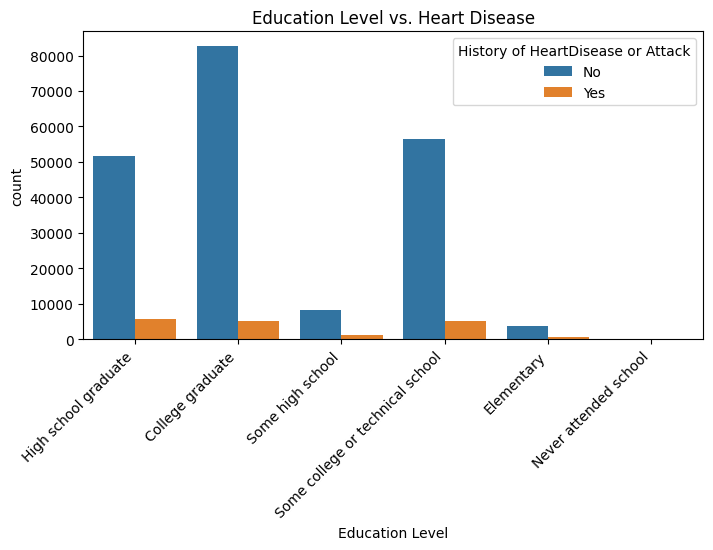

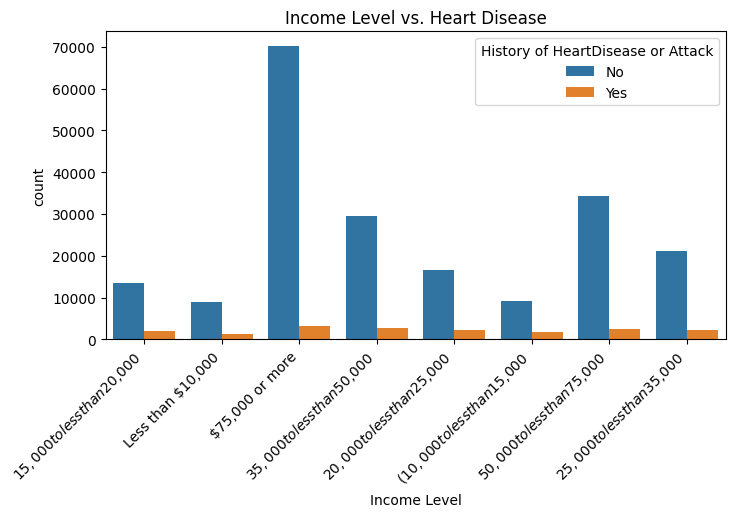

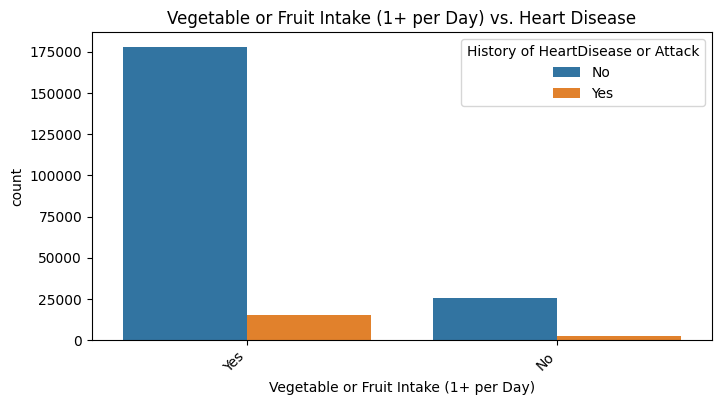

In [14]:
categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'object' and col != 'ID' and col != 'History of HeartDisease or Attack']
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=train_df, hue='History of HeartDisease or Attack') # ดูเทียบกับ target
    plt.title(f'{col} vs. Heart Disease')
    plt.xticks(rotation=45, ha='right')  # หมุน x-axis labels
    plt.show()

In [15]:
# เติมค่าของ History of HeartDisease or Attack ด้วย Mode (ค่าที่พบบ่อยที่สุด)
mode_value = train_df['History of HeartDisease or Attack'].mode()[0]
train_df['History of HeartDisease or Attack'].fillna(mode_value, inplace=True)

train_df['Told High Cholesterol'].fillna(train_df['Told High Cholesterol'].mode()[0], inplace=True)

train_df['Body Mass Index'] = (
    train_df.groupby(['Leisure Physical Activity', 'Income Level', 'General Health'])['Body Mass Index']
    .transform(lambda x: x.mean() if not x.empty else 'No')
)

# ตรวจสอบผลลัพธ์หลังจากเติมค่า
print(train_df[['History of HeartDisease or Attack', 'Told High Cholesterol', 'Body Mass Index']].isnull().sum())
train_df[['History of HeartDisease or Attack', 'Told High Cholesterol', 'Body Mass Index']].head()


History of HeartDisease or Attack    0
Told High Cholesterol                0
Body Mass Index                      1
dtype: int64


<ipython-input-15-231fb35299cb>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['History of HeartDisease or Attack'].fillna(mode_value, inplace=True)
<ipython-input-15-231fb35299cb>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

,History of HeartDisease or Attack,Told High Cholesterol,Body Mass Index
0,No,Yes,31.076881
1,No,No,28.196901
2,No,Yes,30.479035
3,No,No,27.340133
4,No,Yes,30.187787


In [16]:
train_df = train_df.dropna(subset=['Smoked 100+ Cigarettes', 'Diagnosed Diabetes',
                                     'Doctor Visit Cost Barrier', 'General Health',
                                     'Difficulty Walking'])

In [17]:
print(train_df.isnull().sum())
train_df

ID                                        0
History of HeartDisease or Attack         0
High Blood Pressure                       0
Told High Cholesterol                     0
Cholesterol Checked                       0
Body Mass Index                           0
Smoked 100+ Cigarettes                    0
Diagnosed Stroke                          0
Diagnosed Diabetes                        0
Leisure Physical Activity                 0
Heavy Alcohol Consumption                 0
Health Care Coverage                      0
Doctor Visit Cost Barrier                 0
General Health                            0
Difficulty Walking                        0
Sex                                       0
Education Level                           0
Income Level                              0
Age                                       0
Vegetable or Fruit Intake (1+ per Day)    0
dtype: int64


,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,31.076881,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,28.196901,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,30.479035,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.340133,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,No,Yes,Yes,Yes,30.187787,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223079,train_223080,No,No,No,Yes,27.113184,No,No,No,No,No,Yes,No,Excellent,No,Female,College graduate,"$25,000 to less than $35,000",34,Yes
223080,train_223081,No,Yes,Yes,Yes,30.644863,No,No,No,No,No,Yes,No,Fair,No,Male,College graduate,"$50,000 to less than $75,000",43,Yes
223081,train_223082,No,Yes,Yes,Yes,30.865637,No,No,Yes,No,No,Yes,No,Poor,Yes,Female,Elementary,"$20,000 to less than $25,000",72,No
223082,train_223083,No,No,No,Yes,26.255939,No,No,No,Yes,No,Yes,No,Excellent,No,Female,Some college or technical school,"($10,000 to less than $15,000",28,Yes


In [18]:
print(set(train_df['General Health']))
print(set(train_df['Education Level']))
print(set(train_df['Income Level']))

{'Good', 'Fair', 'Very Poor', 'Excellent', 'Poor'}
{'Some college or technical school', 'College graduate', 'Elementary', 'Never attended school', 'Some high school', 'High school graduate'}
{'$50,000 to less than $75,000', '$35,000 to less than $50,000', '$15,000 to less than $20,000', '($10,000 to less than $15,000', '$75,000 or more', 'Less than $10,000', '$25,000 to less than $35,000', '$20,000 to less than $25,000'}


In [19]:
# ดูค่าทุกค่าในทุกคอลัมน์
for col in train_df.columns:
    print(f"ค่าทั้งหมดในคอลัมน์ '{col}':")
    print(train_df[col].unique())
    print('-' * 50)


ค่าทั้งหมดในคอลัมน์ 'ID':
['train_000001' 'train_000002' 'train_000003' ... 'train_223082'
 'train_223083' 'train_223084']
--------------------------------------------------
ค่าทั้งหมดในคอลัมน์ 'History of HeartDisease or Attack':
['No' 'Yes']
--------------------------------------------------
ค่าทั้งหมดในคอลัมน์ 'High Blood Pressure':
['Yes' 'No']
--------------------------------------------------
ค่าทั้งหมดในคอลัมน์ 'Told High Cholesterol':
['Yes' 'No']
--------------------------------------------------
ค่าทั้งหมดในคอลัมน์ 'Cholesterol Checked':
['Yes' 'No']
--------------------------------------------------
ค่าทั้งหมดในคอลัมน์ 'Body Mass Index':
[31.07688147 28.19690118 30.47903485 27.34013284 30.18778662 27.17068274
 28.7740348  31.61381171 28.3867891  29.0187023  31.45246309 30.20083984
 31.38160943 28.71633141 28.83249691 29.72315972 28.58008687 29.96129216
 27.25754396 25.9054759  30.58865385 25.19315201 30.86563672 28.82939807
 31.75774806 29.89799056 27.34812226 30.79515727 27

In [20]:
# Mapping สำหรับ 'General Health'
mapping_health = {
    'Excellent': 5,
    'Good': 4,
    'Fair': 3,
    'Poor': 2,
    'Very Poor': 1
}
train_df['General Health'] = train_df['General Health'].map(mapping_health)

# Mapping สำหรับ 'Education Level'
mapping_education = {
    'Never attended school': 1,
    'Elementary': 2,
    'Some high school': 3,
    'High school graduate': 4,
    'Some college or technical school': 5,
    'College graduate': 6
}
train_df['Education Level'] = train_df['Education Level'].map(mapping_education)

# Mapping สำหรับ 'Income Level'
mapping_income = {
    'Less than $10,000': 1,
    '($10,000 to less than $15,000': 2,
    '$15,000 to less than $20,000': 3,
    '$20,000 to less than $25,000': 4,
    '$25,000 to less than $35,000': 5,
    '$35,000 to less than $50,000': 6,
    '$50,000 to less than $75,000': 7,
    '$75,000 or more': 8
}
train_df['Income Level'] = train_df['Income Level'].map(mapping_income)

# ตรวจสอบผลลัพธ์
print(set(train_df['General Health']))
print(set(train_df['Education Level']))
print(set(train_df['Income Level']))


{1, 2, 3, 4, 5}
{1, 2, 3, 4, 5, 6}
{1, 2, 3, 4, 5, 6, 7, 8}


In [21]:
train_df

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,31.076881,Yes,No,No,No,No,Yes,No,1,Yes,Female,4,3,64,Yes
1,train_000002,No,No,No,No,28.196901,Yes,No,No,Yes,No,No,Yes,3,No,Female,6,1,50,No
2,train_000003,No,Yes,Yes,Yes,30.479035,No,No,No,No,No,Yes,Yes,1,Yes,Female,4,8,61,Yes
3,train_000004,No,Yes,No,Yes,27.340133,No,No,No,Yes,No,Yes,No,4,No,Female,3,6,74,Yes
4,train_000005,No,Yes,Yes,Yes,30.187787,Yes,No,No,Yes,No,Yes,Yes,1,Yes,Male,3,3,98,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223079,train_223080,No,No,No,Yes,27.113184,No,No,No,No,No,Yes,No,5,No,Female,6,5,34,Yes
223080,train_223081,No,Yes,Yes,Yes,30.644863,No,No,No,No,No,Yes,No,3,No,Male,6,7,43,Yes
223081,train_223082,No,Yes,Yes,Yes,30.865637,No,No,Yes,No,No,Yes,No,2,Yes,Female,2,4,72,No
223082,train_223083,No,No,No,Yes,26.255939,No,No,No,Yes,No,Yes,No,5,No,Female,5,2,28,Yes


In [22]:
# Mapping Yes/No เป็น 1/0
yes_no_columns = [
    'History of HeartDisease or Attack', 'High Blood Pressure', 'Told High Cholesterol',
    'Cholesterol Checked', 'Smoked 100+ Cigarettes', 'Diagnosed Stroke',
    'Diagnosed Diabetes', 'Leisure Physical Activity', 'Heavy Alcohol Consumption',
    'Health Care Coverage', 'Doctor Visit Cost Barrier',
    'Difficulty Walking', 'Vegetable or Fruit Intake (1+ per Day)'
]

for col in yes_no_columns:
    train_df[col] = train_df[col].map({'Yes': 1, 'No': 0})


In [23]:
# Mapping เพศ Female = 0, Male = 1
train_df['Sex'] = train_df['Sex'].map({'Female': 0, 'Male': 1})

In [24]:
# ตรวจสอบว่า map ค่าเรียบร้อยหรือไม่
print(train_df.info())
train_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 223076 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      223076 non-null  object 
 1   History of HeartDisease or Attack       223076 non-null  int64  
 2   High Blood Pressure                     223076 non-null  int64  
 3   Told High Cholesterol                   223076 non-null  int64  
 4   Cholesterol Checked                     223076 non-null  int64  
 5   Body Mass Index                         223076 non-null  float64
 6   Smoked 100+ Cigarettes                  223076 non-null  int64  
 7   Diagnosed Stroke                        223076 non-null  int64  
 8   Diagnosed Diabetes                      223076 non-null  int64  
 9   Leisure Physical Activity               223076 non-null  int64  
 10  Heavy Alcohol Consumption               223076 no

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,0,1,1,1,31.076881,1,0,0,0,0,1,0,1,1,0,4,3,64,1
1,train_000002,0,0,0,0,28.196901,1,0,0,1,0,0,1,3,0,0,6,1,50,0
2,train_000003,0,1,1,1,30.479035,0,0,0,0,0,1,1,1,1,0,4,8,61,1
3,train_000004,0,1,0,1,27.340133,0,0,0,1,0,1,0,4,0,0,3,6,74,1
4,train_000005,0,1,1,1,30.187787,1,0,0,1,0,1,1,1,1,1,3,3,98,1


In [25]:
# ตรวจสอบจำนวนและเปอร์เซ็นต์ของ NaN ในแต่ละคอลัมน์
missing_values = train_df.isnull().sum()
missing_percentage = (missing_values / len(train_df)) * 100
print(pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage}))


                                        Missing Values  Percentage
ID                                                   0         0.0
History of HeartDisease or Attack                    0         0.0
High Blood Pressure                                  0         0.0
Told High Cholesterol                                0         0.0
Cholesterol Checked                                  0         0.0
Body Mass Index                                      0         0.0
Smoked 100+ Cigarettes                               0         0.0
Diagnosed Stroke                                     0         0.0
Diagnosed Diabetes                                   0         0.0
Leisure Physical Activity                            0         0.0
Heavy Alcohol Consumption                            0         0.0
Health Care Coverage                                 0         0.0
Doctor Visit Cost Barrier                            0         0.0
General Health                                       0        